#**Diagnóstico Preditivo de Falhas no Sistema APS em Caminhões com Machine Learning**

##**1. Visão Geral do Projeto**

### **Contexto:**

*   Dataset real da Scania (telemetria de caminhões)
*   Problema de classificação binária (falha APS vs não falha)
*   Alto impacto financeiro e operacional

## **2. CRISP-DM - Estrutura Completa do Projeto**

### &nbsp;&nbsp;&nbsp;&nbsp;**2.1. Business Understanding (Entendimento do Negócio)**

- **Objetivo do negócio:**

  - Reduzir falhas críticas no sistema APS
  - Evitar paradas inesperadas de caminhões

- Regra de ouro:

  - Falso Negativo custa 50x mais que Falso Positivo

  - **-> Função de custo:**

    - FP = 10
    - FN = 500

&nbsp;&nbsp;&nbsp;&nbsp;**! Insight forte:**

&nbsp;&nbsp;&nbsp;&nbsp;O problema NÃO é só prever bem, é minimizar custo operacional

### &nbsp;&nbsp;&nbsp;&nbsp;**2.2. Data Understanding (Entendimento dos Dados)**

- **Dataset:**

  - 60k treino / 16k teste
  - 171 variáveis anonimizadas
  - **Dados**:
    - Sensores
    - Histogramas
    - Contadores

- **Target:**

  - 1 → Falha APS
  - 0 → Sem falha APS

&nbsp;&nbsp;&nbsp;&nbsp;**! Insight:**

&nbsp;&nbsp;&nbsp;&nbsp;Dados complexos e de alta dimensionalidade
Possível desbalanceamento (crítico investigar)

### &nbsp;&nbsp;&nbsp;&nbsp; **2.3 Data Preparation (Preparação dos Dados)**

- **Possíveis etapas:**

  - Tratamento de valores faltantes
  - Normalização / padronização
  - Redução de dimensionalidade (PCA)
  - Balanceamento (SMOTE ou class_weight)
  - Seleção de features

  - Insight:

    - Feature engineering pode ser mais importante que o modelo

### &nbsp;&nbsp;&nbsp;&nbsp; **2.4 Modeling (Modelagem)**

- **Modelos a serem testados:**

  - Deep Learning
  - Random Forest
  - XGBoost
  - Regressão Logística
  - SVM / LightGBM

- **Métricas a serem avaliadas:**

  - Acurácia
  - Precision
  - Recall
  - F1-score
  - ROC-AUC

  - **Ponto chave:**

    - Recall é mais importante que precisão nesse problema

### &nbsp;&nbsp;&nbsp;&nbsp; **2.5 Evaluation (Avaliação)**

- **Critério real de sucesso:**

  - Minimizar custo total

  - **Fórmula:**

    - `Custo = (10 × FP) + (500 × FN)`

  - **Insight:**

    - Melhor modelo ≠ maior acurácia
    - Melhor modelo = menor custo

- **Análises importantes:**

  - Overfitting (treino vs teste)
  - Curva ROC
  - Curva de perda

### &nbsp;&nbsp;&nbsp;&nbsp; **2.6 Deployment (Implantação)**

- **Como aplicar no mundo real:**

  - Monitoramento contínuo da frota
  - Alertas preditivos para manutenção
  - Integração com sistemas de manutenção

- **Evolução do projeto:**

  - Dashboard (Streamlit / Power BI)
  - API de predição
  - Pipeline automatizado (DataOps)

## **3. Insights Estratégicos (Slide de Valor)**

- **Principais aprendizados:**
  - O custo do erro muda completamente a estratégia
  - Recall alto salva dinheiro (evita falhas graves)
  - Modelos mais complexos (XGBoost / DL) tendem a performar melhor
  - Feature engineering é crítico

In [ ]:
# ======================================
# DESAFIO | FROTA DE CAMINHOES
# ======================================

import zipfile
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

In [ ]:
import zipfile

# Carregando o dataset zipado do GitHub

github_raw_url = "https://raw.githubusercontent.com/marantmir/pos_graduacao_ia_aplicada_sesi_senai_sc/main/aprendizado_profundo/desafio_frota_caminhoes/aps_failure_test_set.7z"
local_filename = "aps_failure_test_set.7z"

# Baixa o arquivo 7z do GitHub
print(f"Baixando {local_filename} de {github_raw_url}...")
!wget -O {local_filename} {github_raw_url}

# Instala p7zip-full para extrair arquivos .7z
print("Instalando p7zip-full...")
!sudo apt-get update
!sudo apt-get install -y p7zip-full

# Agora, extrai o arquivo .7z localmente usando 7z
print(f"Extraindo {local_filename} com 7z...")
!7z x {local_filename}
print("Extração concluída.")

Baixando aps_failure_test_set.7z de https://raw.githubusercontent.com/marantmir/pos_graduacao_ia_aplicada_sesi_senai_sc/main/aprendizado_profundo/desafio_frota_caminhoes/aps_failure_test_set.7z...
--2026-04-07 22:57:06--  https://raw.githubusercontent.com/marantmir/pos_graduacao_ia_aplicada_sesi_senai_sc/main/aprendizado_profundo/desafio_frota_caminhoes/aps_failure_test_set.7z
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18896181 (18M) [application/octet-stream]
Saving to: ‘aps_failure_test_set.7z’

aps_failure_test_se 100%[===================>]  18.02M  --.-KB/s    in 0.1s    

2026-04-07 22:57:06 (181 MB/s) - ‘aps_failure_test_set.7z’ saved [18896181/18896181]

Instalando p7zip-full...
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https:/

In [ ]:
# O arquivo 'arquivo.zip' não foi encontrado porque o arquivo baixado era 'aps_failure_test_set.7z'
# e ele foi extraído, resultando em arquivos .csv diretamente. Não há um arquivo .zip para abrir.
# Para verificar os arquivos extraídos, podemos listar o conteúdo do diretório atual.

import os

print("Arquivos no diretório atual após a extração:")
for filename in os.listdir('.'):
    print(filename)

Arquivos no diretório atual após a extração:
.config
aps_failure_test_set.7z
aps_failure_training_set.csv
aps_failure_test_set.csv
sample_data


In [ ]:
# 1️ Carregando o dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
colunas = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]
df = pd.read_csv(url, names=colunas)

X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values



5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Médias das métricas (5 folds):
accuracy     0.694805
precision    0.571638
recall       0.578182
f1           0.574427
auc          0.668889
dtype: float64


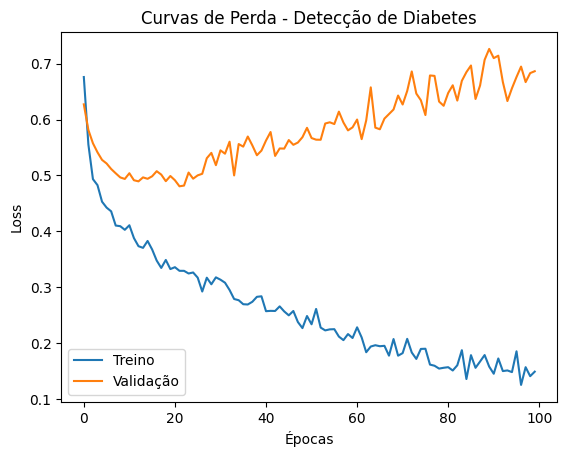

In [ ]:
# 2️ Dividindo dados e normalizando
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3️ Função para construir o modelo
def build_model(optimizer='adam', dropout_rate=0.3):
    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        #layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        #layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        #layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 4️ Early Stopping
#early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 5️ Validação cruzada (K-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
histories = []
scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model = build_model(optimizer='adam', dropout_rate=0.3)
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        #callbacks=[early_stop],
        verbose=0
    )

    histories.append(history)
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    scores.append({
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_pred)
    })

# 6️ Resultados médios
results_df = pd.DataFrame(scores)
print("\nMédias das métricas (5 folds):")
print(results_df.mean())

# 7️ Curva de perda para análise de overfitting
import matplotlib.pyplot as plt
plt.plot(histories[-1].history['loss'], label='Treino')
plt.plot(histories[-1].history['val_loss'], label='Validação')
plt.legend()
plt.title('Curvas de Perda - Detecção de Diabetes')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.show()
